# Growth of FIFA Women's World Cup from 1991-2023

# 1. Introduction

The FIFA Women's World Cup is the premier international competition in women's football, organized by the Fédération Internationale de Football Association (FIFA). Since the inaugural tournament in 1991, the competition has grown significantly in terms of participating nations, global viewership, and commercial investment, reflecting the increasing popularity of women's football worldwide (FIFA, n.d.).

This project uses Python to analyze participation trends in the FIFA Women's World Cup across different tournament editions. The analysis focuses on examining the number of participating countries, geographical representation, and the expansion of the competition over time. By exploring historical tournament data, the project aims to identify patterns that demonstrate the growth and globalization of women's football.

Data processing and visualization techniques are applied using Python libraries to transform raw tournament information into meaningful insights. Through exploratory data analysis and visual storytelling, the project highlights how the FIFA Women's World Cup has evolved from a relatively small competition into one of the most prominent international sporting events for women (FIFA, n.d.; FIFA Women's World Cup, 2025).

## References

FIFA. (n.d.). *Women's football*. FIFA. Retrieved June 13, 2026, from https://inside.fifa.com/womens-football

FIFA Women's World Cup. (2025). In *Wikipedia*. Retrieved June 13, 2026, from https://en.wikipedia.org/wiki/FIFA_Women%27s_World_Cup


# 2. Data Collection

In [57]:
# Scrape List of Teams participated in the womens football 

In [72]:
import requests

world_cups = {
    1991: "https://en.wikipedia.org/wiki/1991_FIFA_Women%27s_World_Cup",
    1995: "https://en.wikipedia.org/wiki/1995_FIFA_Women%27s_World_Cup",
    1999: "https://en.wikipedia.org/wiki/1999_FIFA_Women%27s_World_Cup",
    2003: "https://en.wikipedia.org/wiki/2003_FIFA_Women%27s_World_Cup",
    2007: "https://en.wikipedia.org/wiki/2007_FIFA_Women%27s_World_Cup",
    2011: "https://en.wikipedia.org/wiki/2011_FIFA_Women%27s_World_Cup",
    2015: "https://en.wikipedia.org/wiki/2015_FIFA_Women%27s_World_Cup",
    2019: "https://en.wikipedia.org/wiki/2019_FIFA_Women%27s_World_Cup",
    2023: "https://en.wikipedia.org/wiki/2023_FIFA_Women%27s_World_Cup"
}

In [75]:
all_teams = []

headers = {"User-Agent": "Mozilla/5.0"}

for year, url in world_cups.items():

    print(f"Processing {year}")

    html = requests.get(url, headers=headers).text
    tables = pd.read_html(html)

    tournament_teams = set()

    for table in tables:

        # Flatten MultiIndex columns
        cols = [str(col) for col in table.columns]

        if any("Team" in col for col in cols):

            for col in table.columns:

                if "Team" in str(col):

                    teams = table[col].dropna().astype(str)

                    for team in teams:

                        # Remove obvious junk
                        if len(team) > 2:
                            tournament_teams.add(team)

    print(f"{year}: {len(tournament_teams)} teams found")

    for team in tournament_teams:
        all_teams.append({
            "Year": year,
            "Country": team
        })

Processing 1991


/var/folders/hz/dnw938k10kq7f57wv38p_pfh0000gn/T/ipykernel_4166/1989238088.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


1991: 12 teams found
Processing 1995


/var/folders/hz/dnw938k10kq7f57wv38p_pfh0000gn/T/ipykernel_4166/1989238088.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


1995: 12 teams found
Processing 1999


...

/var/folders/hz/dnw938k10kq7f57wv38p_pfh0000gn/T/ipykernel_4166/1989238088.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


2015: 24 teams found
Processing 2019


/var/folders/hz/dnw938k10kq7f57wv38p_pfh0000gn/T/ipykernel_4166/1989238088.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


2019: 25 teams found
Processing 2023
2023: 34 teams found


/var/folders/hz/dnw938k10kq7f57wv38p_pfh0000gn/T/ipykernel_4166/1989238088.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


In [76]:
# Check DataFrame
df = pd.DataFrame(all_teams)

print(df.groupby("Year").size())

Year
1991    12
1995    12
1999    16
2003    16
2007    16
2011    16
2015    24
2019    25
2023    34
dtype: int64


In [61]:
# Should be 168 teams
print(df.shape[0])

171


In [ ]:
# Scrape All Teams

In [94]:
appearances.head()

,Country,count
0,Sweden,9
1,Japan,9
2,Germany,9
3,Nigeria,9
4,Brazil,9


In [95]:
appearances.columns = ["Country", "Appearances"]

# 3. Data Cleaning and Preparation

In [79]:
df["Country"] = (
    df["Country"]
    .str.replace(r"\s*\(H\)", "", regex=True)
    .str.strip()
)
df = df[df["Country"] != "Great Britain"]

In [80]:
df = df.drop_duplicates(
    subset=["Year", "Country"]
)

In [81]:
print(df.groupby("Year").size())

Year
1991    12
1995    12
1999    16
2003    16
2007    16
2011    16
2015    24
2019    24
2023    32
dtype: int64


In [82]:
print(len(df))

168


In [83]:
appearances = (
    df["Country"]
    .value_counts()
    .reset_index()
)

In [92]:
print(df.columns)

Index(['Year', 'Teams'], dtype='object')


# 4. Visualisation

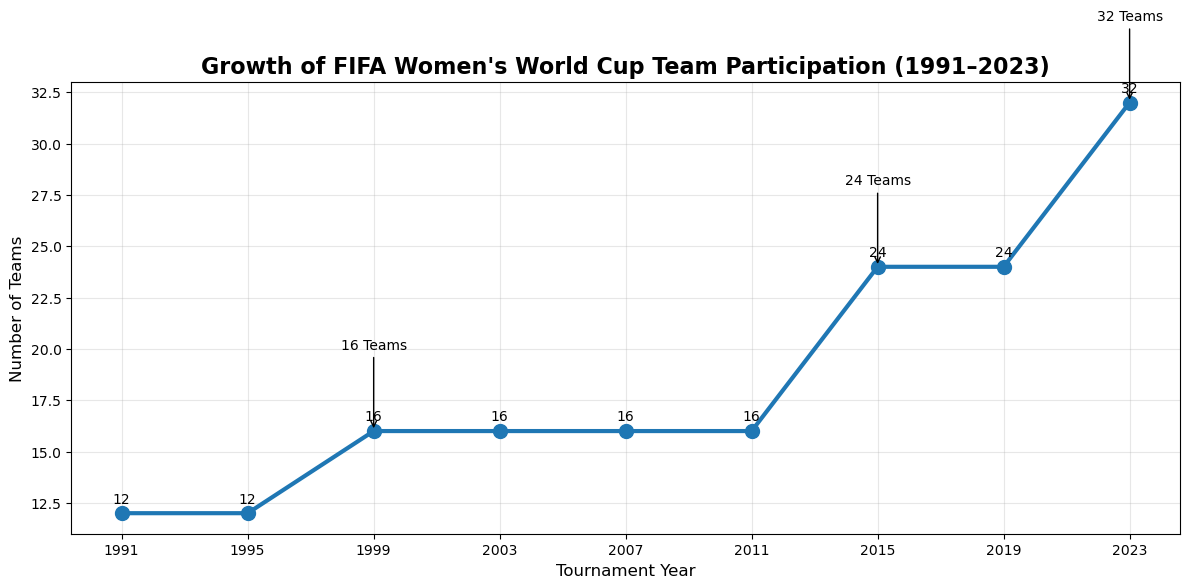

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

# FIFA Women's World Cup participation data
df = pd.DataFrame({
    "Year": [1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019, 2023],
    "Teams": [12, 12, 16, 16, 16, 16, 24, 24, 32]
})

# Create figure
plt.figure(figsize=(12, 6))

# Line plot
plt.plot(
    df["Year"],
    df["Teams"],
    marker="o",
    linewidth=3,
    markersize=10
)

# Add labels above points
for x, y in zip(df["Year"], df["Teams"]):
    plt.text(x, y + 0.5, str(y), ha="center", fontsize=10)

# Highlight expansion years
expansions = {
    1999: "16 Teams",
    2015: "24 Teams",
    2023: "32 Teams"
}

for year, label in expansions.items():
    teams = df.loc[df["Year"] == year, "Teams"].iloc[0]
    plt.annotate(
        label,
        xy=(year, teams),
        xytext=(year, teams + 4),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10,
        ha="center"
    )

# Formatting
plt.title(
    "Growth of FIFA Women's World Cup Team Participation (1991–2023)",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Tournament Year", fontsize=12)
plt.ylabel("Number of Teams", fontsize=12)
plt.xticks(df["Year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
# Heatmap of Participants from 1999-2023

In [97]:
print(appearances.columns)

Index(['Country', 'Appearances'], dtype='object')


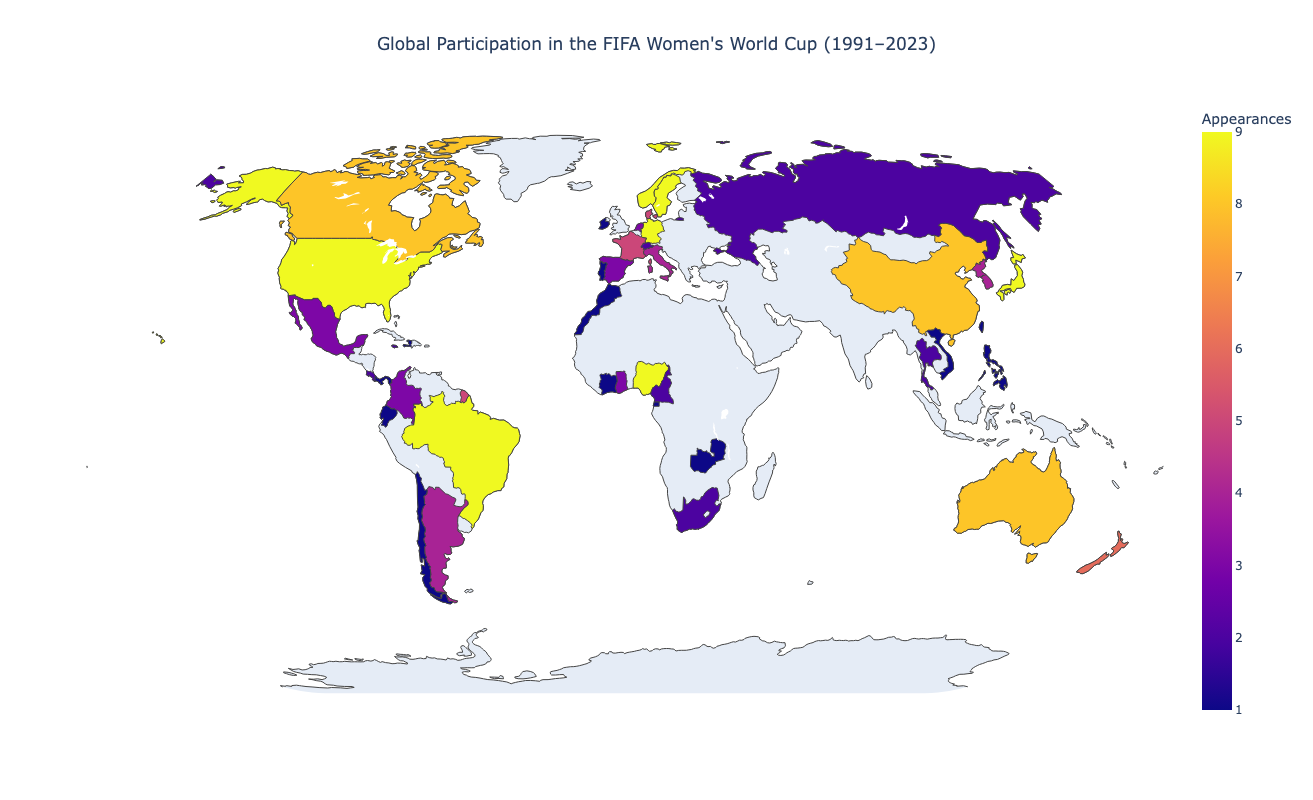

In [106]:
import plotly.express as px

fig = px.choropleth(
    appearances,
    locations="Country",
    locationmode="country names",
    color="Appearances",
    hover_name="Country",
    hover_data=["Appearances"],
    color_continuous_scale="Plasma",
    title="Global Participation in the FIFA Women's World Cup (1991–2023)"
)

fig.update_geos(
    projection_type="natural earth",
    showframe=False,
    showcoastlines=True
)

fig.update_layout(
    title_x=0.5
)

fig.update_layout(
    width=1000,
    height=800,
    title_x=0.5
)
fig.show()

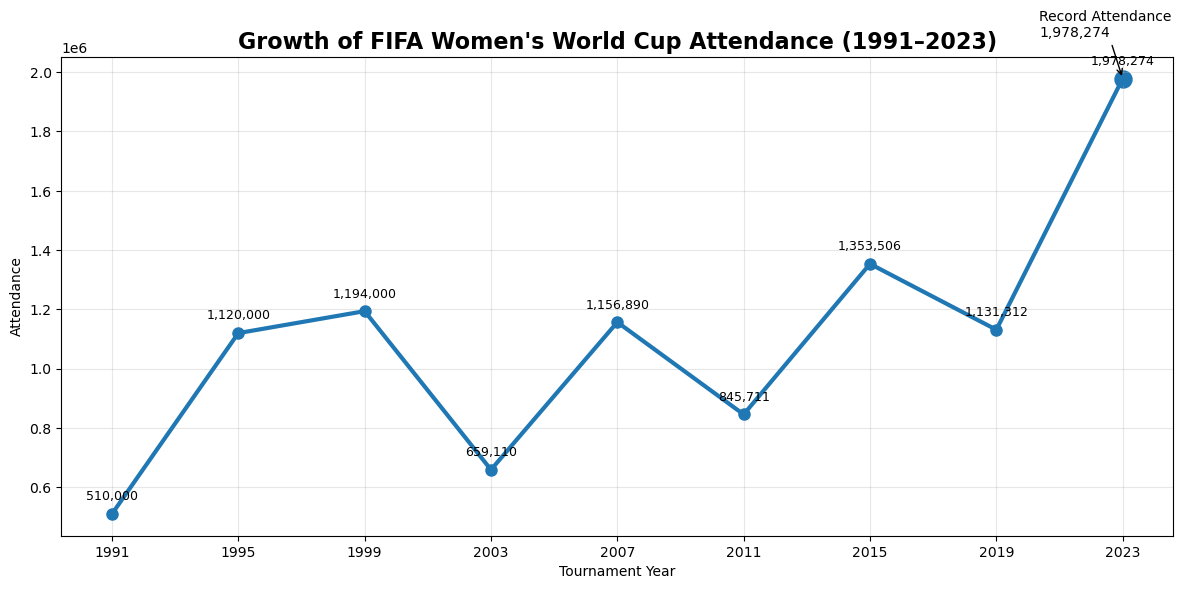

In [112]:
attendance = pd.DataFrame({
    "Year": [1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019, 2023],
    "Attendance": [
        510000,
        1120000,
        1194000,
        659110,
        1156890,
        845711,
        1353506,
        1131312,
        1978274
    ]
})

plt.figure(figsize=(12, 6))

plt.plot(
    attendance["Year"],
    attendance["Attendance"],
    marker="o",
    linewidth=3,
    markersize=8
)

# Add attendance labels above each point
for x, y in zip(attendance["Year"], attendance["Attendance"]):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

plt.title(
    "Growth of FIFA Women's World Cup Attendance (1991–2023)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tournament Year")
plt.ylabel("Attendance")

plt.xticks(attendance["Year"])

plt.grid(True, alpha=0.3)

plt.scatter(
    2023,
    1978274,
    s=150
)

plt.annotate(
    "Record Attendance\n1,978,274",
    (2023, 1978274),
    xytext=(-60, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

# Women's World Cup attendance nearly quadrupled from about 510,000 spectators in 1991 to almost 2 million in 2023.

# Timelines of Milestones

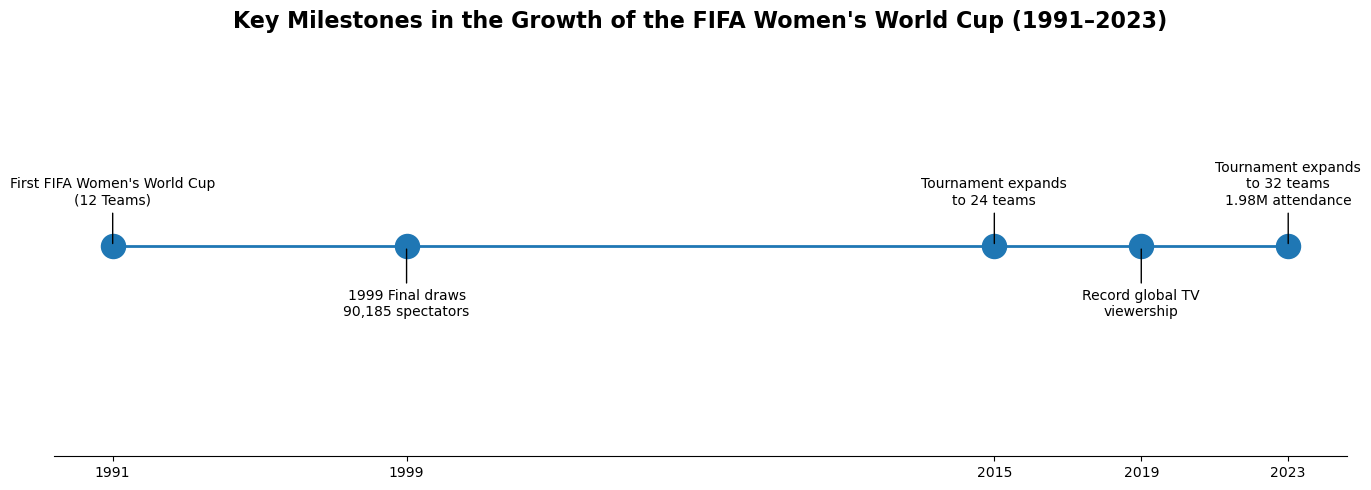

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

milestones = pd.DataFrame({
    "Year": [1991, 1999, 2015, 2019, 2023],
    "Milestone": [
        "First FIFA Women's World Cup\n(12 Teams)",
        "1999 Final draws\n90,185 spectators",
        "Tournament expands\nto 24 teams",
        "Record global TV\nviewership",
        "Tournament expands\nto 32 teams\n1.98M attendance"
    ]
})

fig, ax = plt.subplots(figsize=(14, 5))

# Timeline
ax.hlines(
    y=0,
    xmin=milestones["Year"].min(),
    xmax=milestones["Year"].max(),
    linewidth=2
)

# Milestone markers
ax.scatter(
    milestones["Year"],
    [0]*len(milestones),
    s=300,
    zorder=3
)

# Labels
for i, row in milestones.iterrows():

    offset = 30 if i % 2 == 0 else -50

    ax.annotate(
        row["Milestone"],
        xy=(row["Year"], 0),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        arrowprops=dict(arrowstyle="-")
    )

ax.set_title(
    "Key Milestones in the Growth of the FIFA Women's World Cup (1991–2023)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xticks(milestones["Year"])
ax.set_yticks([])

for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Conclusion

From 1991 to 2023, the FIFA Women's World Cup evolved from a relatively small 12-team tournament into a truly global sporting event. The expansion to 32 teams, increasing participation from nations across every continent, and record-breaking attendance figures demonstrate the rapid growth of women's football over the past three decades.

The visualizations revealed three key trends. First, participation became increasingly global, with more countries qualifying and competing on the world stage. Second, fan engagement grew substantially, with tournament attendance rising from approximately 510,000 spectators in 1991 to nearly 2 million in 2023. Third, FIFA's continued investment in the competition led to tournament expansion, creating opportunities for emerging football nations such as the Philippines, Vietnam, Morocco, and Zambia to make their World Cup debuts.

Overall, the data suggests that the FIFA Women's World Cup is no longer a niche competition but a major international sporting event. The growth in participation, audience size, and global representation highlights the increasing popularity, visibility, and commercial significance of women's football worldwide. As more nations invest in women's programs and pathways, the trajectory shown in this analysis indicates that the sport is likely to continue expanding in both reach and influence in future tournaments.

# In just 32 years, the FIFA Women's World Cup grew from a 12-team tournament into a global competition featuring 32 nations, nearly 2 million spectators, and representation from every footballing continent.